# Phase 8: Genre Evolution Analysis

This section analyzes how movie genres have evolved across different decades.

The analysis focuses on:
- Genre production share across decades
- Growth and decline of genres over time
- Emerging and declining genres
- Long-term changes in genre popularity

> Note: Since movies can belong to multiple genres, genre shares are calculated independently and may sum to more than 100% within a decade.

In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/movies_feature_engineered.csv")

# Convert genre_list back to Python lists
df["genre_list"] = df["genre_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (569655, 46)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,genre_list,averageRating,numVotes,year,...,genre_sport,genre_talk_show,genre_thriller,genre_war,genre_western,runtime_category,rating_category,log_votes,popularity_category,rating_popularity_score
0,tt0000574,movie,The Story of the Kelly Gang,1906,70.0,"Action,Adventure,Biography","[Action, Adventure, Biography]",6.0,1084.0,1906,...,0,0,0,0,0,Short,Average,6.989335,Popular,41.936012
1,tt0000591,movie,The Prodigal Son,1907,90.0,Drama,[Drama],4.8,40.0,1907,...,0,0,0,0,0,Medium,Low,3.713572,Low,17.825146
2,tt0000615,movie,Robbery Under Arms,1907,NaN,Drama,[Drama],3.4,36.0,1907,...,0,0,0,0,0,Unknown,Low,3.610918,Low,12.277121
3,tt0000630,movie,Hamlet,1908,NaN,Drama,[Drama],3.0,42.0,1908,...,0,0,0,0,0,Unknown,Low,3.761200,Low,11.283600
4,tt0000675,movie,Don Quijote,1908,NaN,Drama,[Drama],3.8,32.0,1908,...,0,0,0,0,0,Unknown,Low,3.496508,Low,13.286729


In [2]:
genre_decade_counts = (
    df.explode("genre_list")
      .groupby(["decade", "genre_list"])
      .size()
      .reset_index(name="movie_count")
)

# Total movies in each decade
decade_totals = (
    genre_decade_counts
    .groupby("decade")["movie_count"]
    .sum()
    .reset_index(name="total_genre_counts")
)

# Calculate genre share within each decade
genre_decade_share = genre_decade_counts.merge(
    decade_totals,
    on="decade"
)

genre_decade_share["genre_share_percent"] = (
    genre_decade_share["movie_count"]
    / genre_decade_share["total_genre_counts"]
    * 100
)

display(
    genre_decade_share
    .sort_values(["decade", "genre_share_percent"], ascending=[True, False])
    .head(20)
)

,decade,genre_list,movie_count,total_genre_counts,genre_share_percent
4,1900,Documentary,71,137,51.824818
5,1900,Drama,20,137,14.598540
14,1900,Sport,9,137,6.569343
3,1900,Comedy,6,137,4.379562
15,1900,War,5,137,3.649635
2,1900,Biography,4,137,2.919708
12,1900,News,4,137,2.919708
1,1900,Adventure,3,137,2.189781
8,1900,History,3,137,2.189781
11,1900,Musical,3,137,2.189781


genre_list,Action,Comedy,Crime,Documentary,Drama,Horror,Romance,Thriller
decade,,,,,,,,
1900,1.46,4.38,NaN,51.82,14.60,0.73,0.73,NaN
1910,2.09,11.27,6.65,3.74,55.24,0.60,5.78,0.86
1920,3.53,11.70,4.11,3.95,49.50,0.54,8.38,0.60
1930,3.06,16.51,6.08,5.47,37.05,0.64,10.14,0.65
1940,2.95,16.05,5.78,2.83,33.02,0.90,8.63,1.10
1950,3.77,15.06,6.29,3.68,34.72,1.07,8.18,1.61
1960,7.52,13.98,6.80,4.33,31.74,1.71,8.01,2.51
1970,7.87,13.38,6.12,6.66,29.71,2.87,6.15,2.87
1980,8.77,12.96,5.03,7.56,29.20,3.15,5.70,3.40


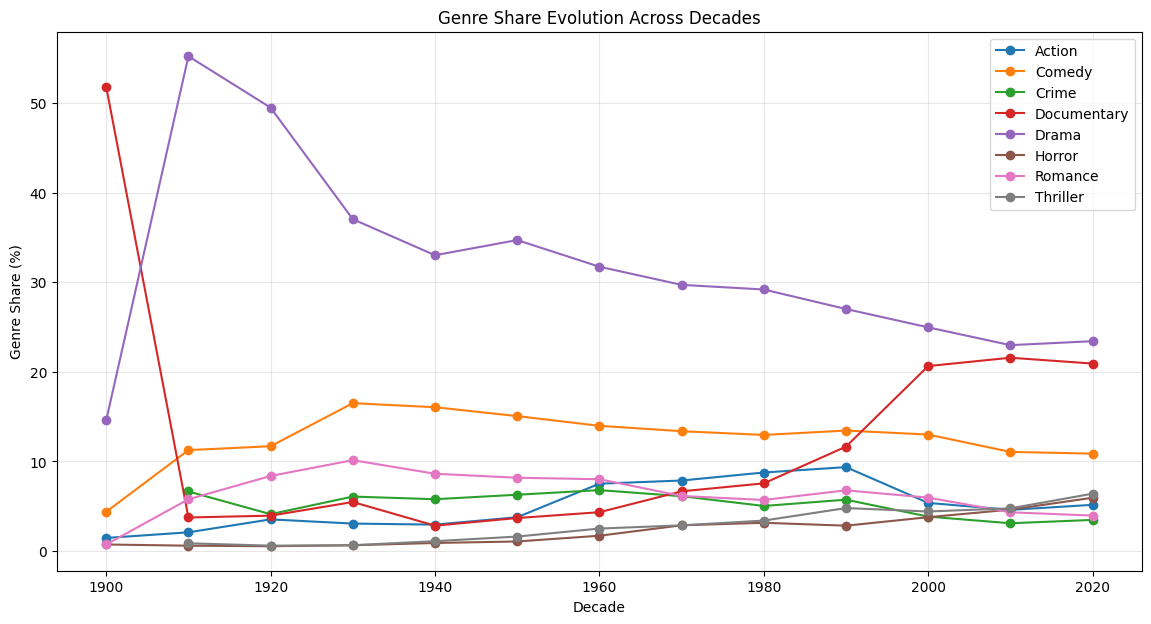

In [3]:
# Select major genres based on overall movie count
top_genres = (
    genre_decade_counts
    .groupby("genre_list")["movie_count"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

# Keep only major genres
genre_share_trend = genre_decade_share[
    genre_decade_share["genre_list"].isin(top_genres)
]

# Pivot for easier analysis
genre_share_pivot = (
    genre_share_trend
    .pivot(
        index="decade",
        columns="genre_list",
        values="genre_share_percent"
    )
)

display(genre_share_pivot.round(2))


# Plot genre share evolution
plt.figure(figsize=(14, 7))

for genre in genre_share_pivot.columns:
    plt.plot(
        genre_share_pivot.index,
        genre_share_pivot[genre],
        marker="o",
        label=genre
    )

plt.title("Genre Share Evolution Across Decades")
plt.xlabel("Decade")
plt.ylabel("Genre Share (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [5]:
# Compare genre shares between the earliest and latest decades
first_decade = genre_share_pivot.index.min()
last_decade = genre_share_pivot.index.max()

# Missing genre shares mean the genre was not present in that decade
genre_change = pd.DataFrame({
    "first_decade_share": genre_share_pivot.loc[first_decade].fillna(0),
    "last_decade_share": genre_share_pivot.loc[last_decade].fillna(0)
})

# Absolute change in percentage points
genre_change["change_percentage_points"] = (
    genre_change["last_decade_share"]
    - genre_change["first_decade_share"]
)

# Relative percentage change
genre_change["relative_change_percent"] = genre_change.apply(
    lambda row:
        ((row["last_decade_share"] - row["first_decade_share"])
         / row["first_decade_share"] * 100)
        if row["first_decade_share"] > 0
        else None,
    axis=1
)

genre_change = genre_change.sort_values(
    "change_percentage_points",
    ascending=False
)

print(f"Comparison: {first_decade}s → {last_decade}s")

display(genre_change.round(2))

Comparison: 1900s → 2020s


,first_decade_share,last_decade_share,change_percentage_points,relative_change_percent
genre_list,,,,
Drama,14.60,23.43,8.83,60.47
Comedy,4.38,10.87,6.49,148.22
Thriller,0.00,6.40,6.40,NaN
Horror,0.73,5.95,5.22,715.18
Action,1.46,5.16,3.70,253.20
Crime,0.00,3.47,3.47,NaN
Romance,0.73,3.95,3.22,441.62
Documentary,51.82,20.93,-30.90,-59.62


In [6]:
# Identify growing and declining genres

growing_genres = (
    genre_change[
        genre_change["change_percentage_points"] > 0
    ]
    .sort_values(
        "change_percentage_points",
        ascending=False
    )
)

declining_genres = (
    genre_change[
        genre_change["change_percentage_points"] < 0
    ]
    .sort_values(
        "change_percentage_points",
        ascending=True
    )
)

print("Growing Genres:")
display(
    growing_genres[
        [
            "first_decade_share",
            "last_decade_share",
            "change_percentage_points"
        ]
    ].round(2)
)

print("Declining Genres:")
display(
    declining_genres[
        [
            "first_decade_share",
            "last_decade_share",
            "change_percentage_points"
        ]
    ].round(2)
)

Growing Genres:


,first_decade_share,last_decade_share,change_percentage_points
genre_list,,,
Drama,14.60,23.43,8.83
Comedy,4.38,10.87,6.49
Thriller,0.00,6.40,6.40
Horror,0.73,5.95,5.22
Action,1.46,5.16,3.70
Crime,0.00,3.47,3.47
Romance,0.73,3.95,3.22


Declining Genres:


,first_decade_share,last_decade_share,change_percentage_points
genre_list,,,
Documentary,51.82,20.93,-30.9


### Key Insight

Genre production shares have changed significantly between the 1900s and the 2020s.

Drama remained one of the most prominent genres and increased its production share from 14.60% to 23.43%. Comedy also showed strong growth, increasing from 4.38% to 10.87%.

Thriller, Horror, Action, Crime, and Romance also increased their production shares over the period, indicating growing diversification in movie genres.

In contrast, Documentary showed a substantial decline in production share, falling from 51.82% in the 1900s to 20.93% in the 2020s.

Overall, the analysis suggests a shift from early dominance of Documentary films toward a more diverse genre landscape dominated by Drama, Comedy, and other narrative genres.

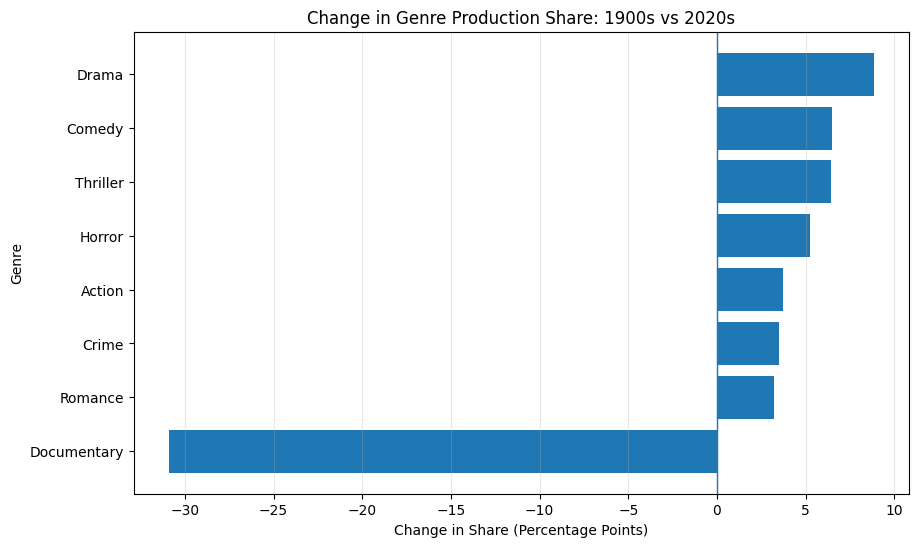

In [7]:
plt.figure(figsize=(10, 6))

plot_data = genre_change.sort_values(
    "change_percentage_points"
)

plt.barh(
    plot_data.index,
    plot_data["change_percentage_points"]
)

plt.title("Change in Genre Production Share: 1900s vs 2020s")
plt.xlabel("Change in Share (Percentage Points)")
plt.ylabel("Genre")

plt.axvline(0, linewidth=1)
plt.grid(axis="x", alpha=0.3)

plt.show()

### Key Insight

The comparison between the 1900s and 2020s shows a major shift in genre production patterns.
Drama experienced the largest increase in production share, rising by 8.83 percentage points. Comedy and Thriller also showed substantial growth, while Horror, Action, Crime, and Romance gained production share over time.
Documentary was the only major genre to show a significant decline, decreasing by 30.90 percentage points from the 1900s to the 2020s.
Overall, movie production has become more diversified, with narrative and entertainment-focused genres gaining a larger share over time.

### Overall Genre Evolution Summary

The genre evolution analysis reveals substantial changes in movie production patterns from the 1900s to the 2020s.

Drama remained a consistently important genre and increased its production share from 14.60% to 23.43%. Comedy also experienced strong growth, increasing from 4.38% to 10.87%. Thriller, Horror, Action, Crime, and Romance also gained production share over the same period.
Documentary showed the most significant decline, falling from 51.82% of genre production share in the 1900s to 20.93% in the 2020s.
The emergence and growth of genres such as Thriller and Crime further indicate that the movie industry has diversified considerably over time.
Overall, the analysis suggests a long-term transition from a production landscape heavily dominated by Documentary films toward a more diverse ecosystem led by Drama, Comedy, and other narrative genres.

### Phase 8 Conclusion

Genre production has evolved considerably across the decades.
The analysis shows that:
- Drama has remained one of the most dominant genres and increased its share over time.
- Comedy has experienced substantial long-term growth.
- Thriller, Horror, Action, Crime, and Romance have also expanded their production presence.
- Documentary experienced the largest decline in production share.
- The overall genre landscape has become more diversified in recent decades.
These findings provide evidence of a long-term transformation in movie production preferences and establish a foundation for further analysis of audience ratings, popularity, and movie characteristics.